In [1]:
!nvidia-smi

Tue Mar 17 16:49:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:AF:00.0 Off |                    0 |
| N/A   39C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Reproducing using Qwen-0.6B

In [2]:
## Install first, it will reset the environment
!pip install sae-lens

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of transformer-lens to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 29.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 41.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 96.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 60.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [3]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 94.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 101.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]


In [4]:
# === Imports ===
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, BitsAndBytesConfig, AutoTokenizer
from huggingface_hub import hf_hub_download, notebook_login, snapshot_download
from sae_lens import SAE

torch.set_grad_enabled(False) # avoid blowing up mem

# Colab only: uncomment to mount Google Drive
# from google.colab import drive
# drive.mount('/gdrive')

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [ ]:
# %cd /gdrive/MyDrive/Colab Notebooks

/gdrive/MyDrive/Colab Notebooks


### Download Model

In [8]:
# Uncomment to download the model

repo_id = "Qwen/Qwen3-0.6B" # google/gemma-2-2b
local_model_path = "SNLP/qwen06b_local"

# This actually performs the download
snapshot_download(
    repo_id=repo_id,
    local_dir=local_model_path,
    # token=hf_token # You can either specify your token here or add it to your colab secrets
)

print(f"Model downloaded to {local_model_path}")

Fetching 10 files: 100%|██████████| 10/10 [00:13<00:00,  1.31s/it]

Model downloaded to SNLP/qwen06b_local


#### Intializing the LLM (Qwen or Gemma)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
local_model_path = "SNLP/qwen06b_local"  # This is where the files will be saved

model = AutoModelForCausalLM.from_pretrained(
    local_model_path,       # Point to the local directory
    device_map='auto',
    local_files_only=True,  # Optional: safety check to ensure it doesn't try to go online
)

tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)

print("Model and Tokenizer loaded successfully from local storage.")

Loading weights: 100%|██████████| 311/311 [00:01<00:00, 196.65it/s]
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model and Tokenizer loaded successfully from local storage.


In [12]:
# uncomment to login your hugging face token -> prefer using secret from colab
# notebook_login()

In [7]:
release = "mwhanna-qwen3-0.6b-transcoders-lowl0"
sae_id = "layer_18"
sae = SAE.from_pretrained(release, sae_id).to(device)
target_layer = 18

/opt/python/lib/python3.13/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [8]:
import requests
import json

# Download multilingual dataset from GitHub
data_url = "https://raw.githubusercontent.com/Aatrox103/multilingual-llm-features/main/SAE/data/multilingual_data.jsonl"
response = requests.get(data_url)
response.raise_for_status()  # Raise error if download failed

# Each line in .jsonl is a JSON object (typically with 'text' and maybe 'language')
multilingual_texts = []
for line in response.text.strip().split('\n'):
    obj = json.loads(line)
    if isinstance(obj, dict) and 'text' in obj:
        multilingual_texts.append(obj['text'])
    elif isinstance(obj, str):
        multilingual_texts.append(obj)

# If you want only a small sample (for speed), you can do e.g.:
# multilingual_texts = multilingual_texts[:10]

# Example: print a sample
print("Sample multilingual texts:", multilingual_texts[:3])

Sample multilingual texts: ['The pilot was identified as Squadron Leader Dilokrit Pattavee.', 'Local media reports an airport fire vehicle rolled over while responding.', '28-year-old Vidal had joined Barça three seasons ago, from Sevilla.']


In [9]:
target_lan = ['en', 'es', 'fr', 'ja', 'ko', 'pt', 'th', 'vi', 'zh', 'ar']

#### Unit Test with LLM and SAE

In [10]:
dummy_text = "Who are you?"
inputs = tokenizer.encode(dummy_text, return_tensors='pt', add_special_tokens=True).to(device)
output = model.generate(inputs, max_new_tokens=20)
print(tokenizer.decode(output[0], skip_special_tokens=True))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Who are you? What are your core values?

As a digital marketing professional, how can I apply these values to my


#### Calculating their proposed score - Toy example

In [11]:
def gather_residual_activations(model, target_layer, inputs):
  target_act = None
  def gather_target_act_hook(mod, inputs, outputs):
    nonlocal target_act # make sure we can modify the target_act from the outer scope
    target_act = outputs[0]
    return outputs
  handle = model.model.layers[target_layer].register_forward_hook(gather_target_act_hook)
  _ = model.forward(inputs)
  handle.remove()
  return target_act

In [12]:
texts = ["The pilot was identified as Squadron Leader Dilokrit Pattavee.",
         "Viên phi công được xác định là Chỉ huy đội bay Dilokrit Pattavee.",
         "Le pilote a été identifié comme étant le chef d’escadron Dilokrit Pattavee."]

In [13]:
len(multilingual_texts)

1000

In [14]:
# Extract SAE activations for each language (each 100 texts per lan in multilingual_texts)

sae_activations_per_language = {}

for i, lan in enumerate(target_lan):
    lang_texts = multilingual_texts[i*100: (i+1)*100][:10]
    activations = []
    for text in lang_texts:
        inputs = tokenizer.encode(text, return_tensors='pt', add_special_tokens=True)
        inputs = inputs.to(device)
        target_act = gather_residual_activations(model, target_layer, inputs)
        sae_act = sae.encode(target_act).cpu()
        if len(sae_act.shape) == 2:
            sae_act = sae_act.unsqueeze(0)
        activations.append(sae_act)
    sae_activations_per_language[lan] = activations

# Example: print the shape of first language's first activation
first_lan = target_lan[0]
print(f"First SAE activation shape for {first_lan}:", sae_activations_per_language[first_lan][0].shape)

First SAE activation shape for en: torch.Size([1, 14, 163840])


In [15]:
avg_act_per_lan = [] #[num_languages, num_features]
for lan in target_lan:
  avg_act_per_lan.append(torch.cat(sae_activations_per_language[lan], dim=1).mean(-2))

top_index_per_lan = []
top_ratio_per_lan = []
v_per_lan = []

avg_act_per_lan = torch.stack(avg_act_per_lan)  # [num_languages, num_features]
for i in range(len(avg_act_per_lan)):

  mean = avg_act_per_lan[i]
  gamma = torch.cat([avg_act_per_lan[:i], avg_act_per_lan[i+1:]]).mean(0)
  v = mean - gamma

  sorted_values, sorted_indices=torch.sort(v, descending=True)

  top_index_per_lan.append(sorted_indices)
  top_ratio_per_lan.append(sorted_values)
  v_per_lan.append(v)

top_ratio_per_lan = torch.cat(top_ratio_per_lan)  # [num_languages, num_features] - but num_features are the nu score of each feature
top_index_per_lan = torch.cat(top_index_per_lan) # [num_languages, num_features] - sorted index of top v
v_per_lan = torch.cat(v_per_lan)  # [num_languages, num_features] - columns ordered by feature index

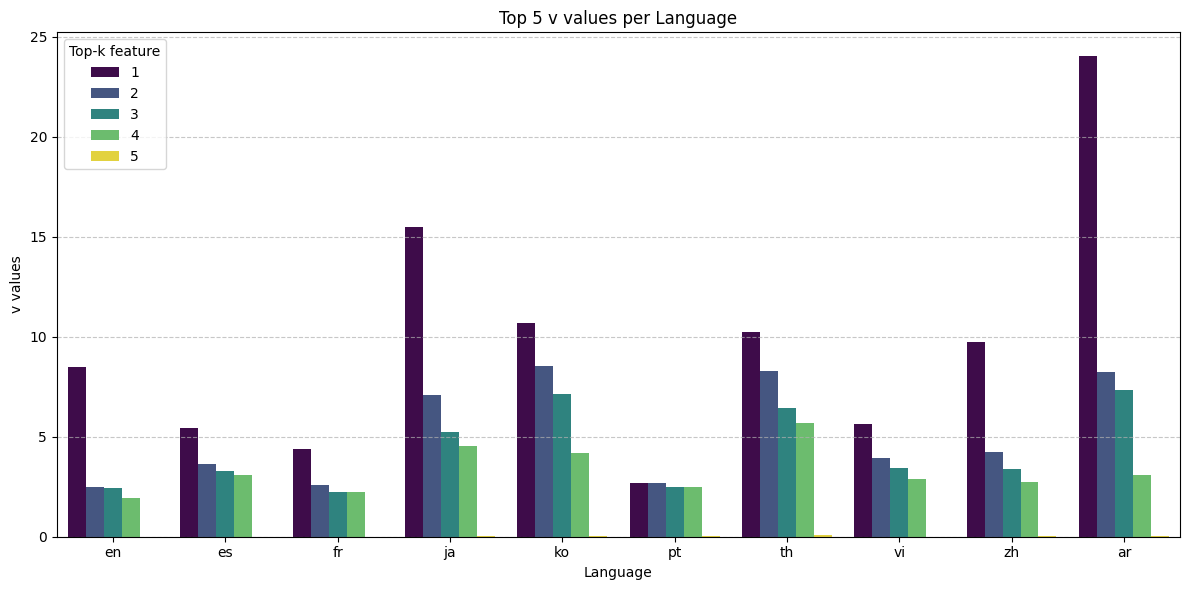

In [16]:

data_for_plot = []

for i in range(len(target_lan)):
    # Concatenate the top 4 values with the 2000th value
    # WARNING : concatenation with the 2000th value is NOT the same as in the paper : should be feature 2000 and not 2000th
    values_to_include = torch.cat([top_ratio_per_lan[i, :4], top_ratio_per_lan[i, 4000][None]]).cpu().numpy()
    for j in range(len(values_to_include)):
        data_for_plot.append({
            'Language': target_lan[i],
            'Feature Rank': j + 1, # Rank within the top 5 for that language
            'Value': values_to_include[j] # Assign individual scalar value
        })

df_plot = pd.DataFrame(data_for_plot)

plt.figure(figsize=(12, 6))
sns.barplot(x='Language', y='Value', hue='Feature Rank', data=df_plot, palette='viridis')
plt.title('Top 5 v values per Language')
plt.ylabel('v values')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Top-k feature')
plt.tight_layout()
plt.show()

The idea for the next figure is to determine if we have overlap in the top features between language.

For example : me way have that top french and spanish feature are the same showing that we have intrinsic superposition of these languages  

Top 1 feature index : [ 53452 145804  21757  38181 139737  34878 114326 154676  27170  25966]


<Figure size 2000x500 with 0 Axes>

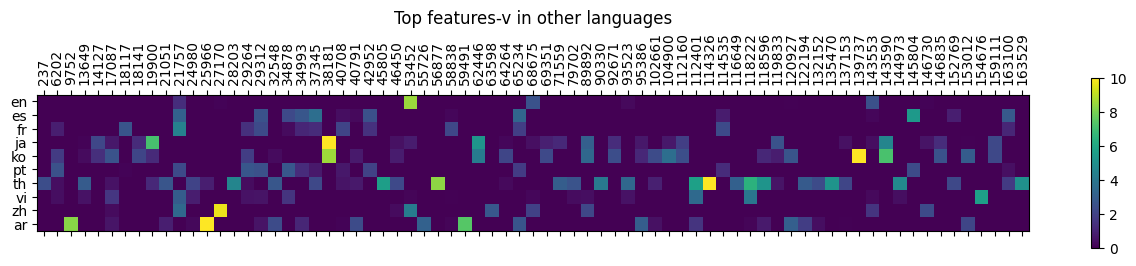

In [17]:
def filter_columns_by_threshold(arr, threshold=2):
    # 1. Identify which columns have at least one value > threshold
    column_mask = np.any(arr > threshold, axis=0)

    # 2. Get the indices of those columns
    indices = np.where(column_mask)[0]

    # 3. Filter the array to keep only those columns
    filtered_arr = arr[:, column_mask]

    return filtered_arr, indices

v_arr = v_per_lan.cpu().numpy().squeeze()
overlapping_index, indices = filter_columns_by_threshold(v_arr, threshold=2)
plt.figure(figsize=(20,5))
# TODO add a label on each square for the top 10 features
plt.matshow(overlapping_index, vmin=0, vmax=10) # Clamp to focus on interesting values
plt.colorbar()
plt.xticks(range(len(indices)), indices, rotation="vertical")
plt.yticks(range(len(target_lan)), target_lan)
plt.title("Top features-v in other languages")
top_1_index = np.argmax(v_arr, axis=1)
print(f"Top 1 feature index : {top_1_index}")

/tmp/ipykernel_3286/321581889.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Language', y='Value', data=feature_df, palette='viridis')


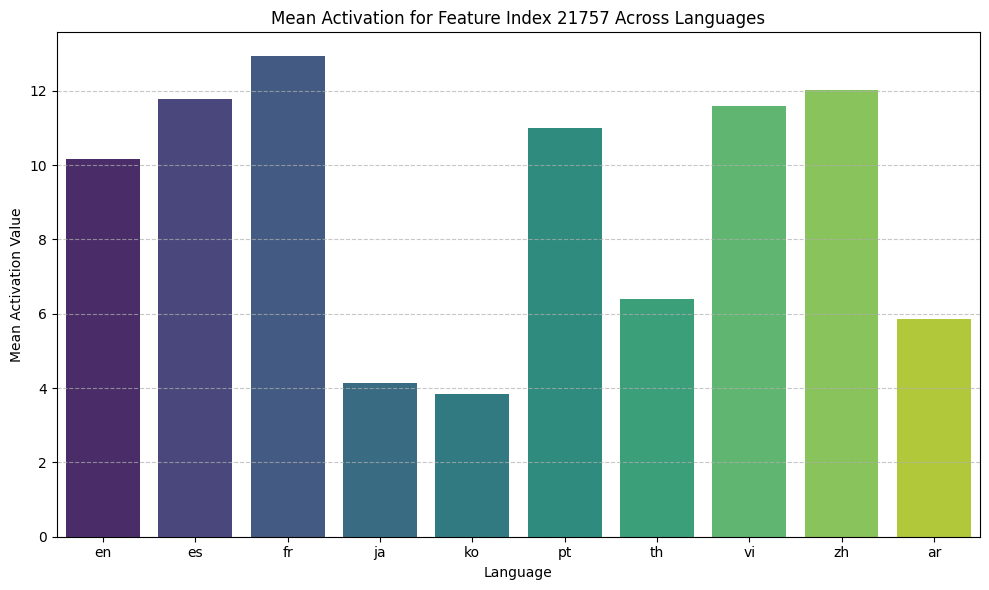

In [18]:
## Mean activation of one feature for many languages##
index = [top_index_per_lan[2][0]]
feature_at_index = avg_act_per_lan[:,:,index] # [num_languages, values]

for i in range(len(index)):
  id = index[i]
  feature_at_index = avg_act_per_lan[:,:,id] # [num_languages, values]


  # Convert the tensor to a pandas DataFrame for plotting
  feature_df = pd.DataFrame({
      'Language': target_lan,
      'Value': feature_at_index.squeeze().cpu().numpy() # Squeeze to remove the extra dimension, convert to numpy
  })

  plt.figure(figsize=(10, 6))
  sns.barplot(x='Language', y='Value', data=feature_df, palette='viridis')
  plt.title(f'Mean Activation for Feature Index {id} Across Languages')
  plt.xlabel('Language')
  plt.ylabel('Mean Activation Value')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

### Ablation

### Code switching

In [25]:
# Uncomment to download locally all SAEs
local_qwen_sae_path = "SNLP/qwen_sae"
sae_qwen_repo = "mwhanna/qwen3-0.6b-transcoders-lowl0"
snapshot_download(
    repo_id=sae_qwen_repo,
    local_dir=local_qwen_sae_path,
    # token=hf_token # You can either specify your token here or add it to your colab secrets
)

Fetching 61 files:   8%|▊         | 5/61 [01:48<20:14, 21.69s/it]
/opt/python/lib/python3.13/site-packages/huggingface_hub/file_download.py:722: UserWarning: Not enough free disk space to download the file. The expected file size is: 1061.13 MB. The target location SNLP/qwen_sae/.cache/huggingface/download/features only has 0.00 MB free disk space.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/huggingface_hub/file_download.py:722: UserWarning: Not enough free disk space to download the file. The expected file size is: 1061.13 MB. The target location SNLP/qwen_sae/features only has 0.00 MB free disk space.
  warnings.warn(


RuntimeError: Data processing error: File reconstruction error: IO Error: No space left on device (os error 28)

In [ ]:
n_layers = 28 # from 0 to 27

local = True
if local:
  release_sae_qwen = "mwhanna-qwen3-0.6b-transcoders-lowl0"
else:
  release_sae_qwen = local_qwen_sae_path

def load_sae_qwen(layer_id):
  sae_id = f"layer_{layer_id}"
  sae = SAE.from_pretrained(release_sae_qwen, sae_id)
  return sae

def load_all_sae_qwen():
  sae_list = []
  for i in range(n_layers):
    sae_id = f"layer_{i}"
    sae = SAE.from_pretrained(release_sae_qwen, sae_id)
    sae_list.append(sae)
  return sae_list

# list_sae = load_all_sae_qwen()

In [ ]:
from functools import partial

def load_jsonl_forced_code_switching():
  url = "https://raw.githubusercontent.com/Aatrox103/multilingual-llm-features/main/SAE/data/forced_code_switch.jsonl"
  response = requests.get(url)
  response.raise_for_status()  # Raise error if download failed

  # Each line in .jsonl is a JSON object (typically with 'text' and maybe 'language')
  sentence_dict_list = []
  for line in response.text.strip().split('\n'):
      obj = json.loads(line)
      sentence_dict_list.append(obj)

  return sentence_dict_list

def get_sentence(lan, sentence_dict_list):
  new_sentence_dict_list = []
  for sentence_dict in sentence_dict_list:
    if sentence_dict["ori_lan"] == lan:
      new_sentence_dict_list.append(sentence_dict)
  return new_sentence_dict_list

load_jsonl_forced_code_switching()[:3]

[{'sentence': 'She had a wonderful time visiting the museum and especially enjoyed the gallery',
  'ori_sentence': 'She had a wonderful time visiting the museum and especially enjoyed the',
  'ori_lan': 'en',
  'target_lan': 'en'},
 {'sentence': 'She had a wonderful time visiting the museum and especially enjoyed the galería',
  'ori_sentence': 'She had a wonderful time visiting the museum and especially enjoyed the',
  'ori_lan': 'en',
  'target_lan': 'es'},
 {'sentence': 'She had a wonderful time visiting the museum and especially enjoyed the galerie',
  'ori_sentence': 'She had a wonderful time visiting the museum and especially enjoyed the',
  'ori_lan': 'en',
  'target_lan': 'fr'}]

In [ ]:

def gather_all_latent_sae(model, list_sae, inputs):
  target_latent = []

  def gather_target_act_hook(mod, inputs, outputs, sae_id=None):
    sae = load_sae_qwen(sae_id)
    sae.to(device) # move sae to device to, TODO check
    target_act = outputs[0]
    sae_act = sae.encode(target_act).cpu()
    if len(sae_act.shape) == 2:
        sae_act = sae_act.unsqueeze(0)
    target_latent.append(sae_act)
    return outputs

  handles = []
  for i, layer in enumerate(model.model.layers):
    handles.append(layer.register_forward_hook(partial(gather_target_act_hook, sae_id=i)))

  _ = model.forward(inputs)

  for handle in handles:
    handle.remove()
  target_latent = torch.cat(target_latent)
  return target_latent


def get_activations_code_switching(ori_lan, target_lan, get_sentence, get_activations_all_layers, target_feature):
  """
  ori_lan, target_lan: str code of language, ex: "fr"
  get_sentence : callable(lan) return all sentences dict with prefix in `lan` language
  get_activations_all_layers : callable(sentence) return all latent activation for each layer
  target_feature: int, index of top feature of ori_lan

  Returns
    ori_lan prefix + ori_lan noun (n_layers,)
    ori_lan prefix + target_lan noun (n_layers,)
    target_lan noun (n_layers,)
  """
  ori_lan_both_activation = []
  ori_lan_prefix_target_noun_activation = []
  target_noun_activation = []

  target_nouns = []

  sentences_dict_list = get_sentence(ori_lan)[:10]
  for sentence_dict in sentences_dict_list:
    if sentence_dict["target_lan"] != target_lan and sentence_dict["target_lan"] != ori_lan:
      continue

    sentence = sentence_dict["sentence"]
    inputs = tokenizer.encode(sentence, return_tensors='pt', add_special_tokens=True)
    inputs = inputs.to(device)
    activations = get_activations_all_layers(inputs=inputs)
    print(activations.shape)
    ori_inputs = tokenizer.encode(sentence_dict["ori_sentence"], return_tensors='pt', add_special_tokens=True)
    print(f"Shape prefix : {ori_inputs.shape[1]}, shape prefix+noun : {inputs.shape[1]}")
    activations = activations[:, ori_inputs.shape[1]:, target_feature] # Take target feature of last word, i.e tokens after
    activations = torch.mean(activations, axis=1) # Average last word over all its tokens

    if sentence_dict["target_lan"] == target_lan:
      target_nouns.append(sentence.split(" ")[-1]) # Add the target_lan noun to a list to process it
      ori_lan_prefix_target_noun_activation.append(activations)
    else: # == ori_len
      ori_lan_both_activation.append(activations)

  for target_noun in target_nouns:
    input = tokenizer.encode(target_noun, return_tensors='pt', add_special_tokens=True)
    input = input.to(device)
    activations = get_activations_all_layers(inputs=input)
    activations = activations[:, :, target_feature]
    activations = torch.mean(activations, axis=1)
    target_noun_activation.append(activations)

  # TODO in future : add std
  # ori_lan_both_activation = torch.cat(ori_lan_both_activation).mean(0) # Average over all sentences
  # ori_lan_prefix_target_noun_activation = torch.cat(ori_lan_prefix_target_noun_activation).mean(0)
  # target_noun_activation = torch.cat(target_noun_activation).mean(0)

  return ori_lan_both_activation, ori_lan_prefix_target_noun_activation, target_noun_activation

sentence_dict_list = load_jsonl_forced_code_switching()
ori_lan = "es"
target_lan = "fr"
get_sentence = partial(get_sentence, sentence_dict_list=sentence_dict_list)
get_activations_all_layers = partial(gather_all_latent_sae, model=model, list_sae=range(n_layers))
target_feature = top_1_index[1] # index corresponds to ori_lan : 1="es"
ori_both_activation, ori_pref_target_noun_activation, target_noun_activation = get_activations_code_switching(ori_lan, target_lan, get_sentence,get_activations_all_layers, target_feature)


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


torch.Size([28, 17, 163840])
Shape prefix : 16, shape prefix+noun : 17
torch.Size([28, 18, 163840])
Shape prefix : 16, shape prefix+noun : 18


In [ ]:
ori_both_activation, ori_pref_target_noun_activation, target_noun_activation = ori_both_activation[0], ori_pref_target_noun_activation[0], target_noun_activation[0]

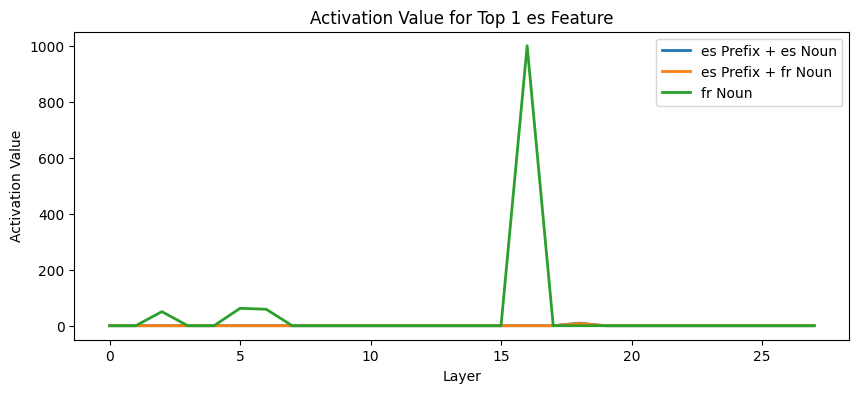

In [ ]:
x = range(n_layers)

def plot_activation_value_layers_for_selected_language():
  plt.figure(figsize=(10, 4))
  plt.plot(x, ori_both_activation, label=f'{ori_lan} Prefix + {ori_lan} Noun', linestyle='-', linewidth=2)
  plt.plot(x, ori_pref_target_noun_activation, label=f'{ori_lan} Prefix + {target_lan} Noun', linestyle='-', linewidth=2)
  plt.plot(x, target_noun_activation, label=f'{target_lan} Noun', linestyle='-', linewidth=2)

  plt.title(f'Activation Value for Top 1 {ori_lan} Feature')
  plt.xlabel('Layer')
  plt.ylabel(f'Activation Value')
  plt.legend()

plot_activation_value_layers_for_selected_language()

#### Directional Ablation - Toy example

In [26]:
from einops import einsum

In [27]:
multilingual_texts[2*100: (2+1)*100][:2]

['Le pilote a été identifié comme étant le chef d’escadron Dilokrit Pattavee.',
 "La presse locale a rapporté qu'un véhicule de lutte contre l'incendie de l'aéroport a fait des tonneaux en portant secours."]

In [28]:
def compute_top_index_per_lan_for_layer(model, sae, layer, target_lan, multilingual_texts, device, n_texts_per_lan=10):
    """Compute top_index_per_lan for a given layer and SAE (same logic as your notebook)."""
    sae_activations_per_language = {}
    for i, lan in enumerate(target_lan):
        lang_texts = multilingual_texts[i * 100 : (i + 1) * 100][:n_texts_per_lan]
        activations = []

        for text in lang_texts:
            inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=True).to(device)
            inputs = inputs.to(device)
            target_act = gather_residual_activations(model, layer, inputs)
            # print(target_act.shape, sae.W_enc.shape)
            sae_act = sae.encode(target_act).cpu()
            if len(sae_act.shape) == 2:
                sae_act = sae_act.unsqueeze(0)
            activations.append(sae_act)
        sae_activations_per_language[lan] = activations

    avg_act_per_lan = []
    for lan in target_lan:
        avg_act_per_lan.append(torch.cat(sae_activations_per_language[lan], dim=1).mean(-2))
    avg_act_per_lan = torch.cat(avg_act_per_lan)  # (num_languages, num_features)

    top_index_per_lan = []
    top_values_per_lan = []
    for i in range(len(avg_act_per_lan)):
        mean = avg_act_per_lan[i]
        gamma = torch.cat([avg_act_per_lan[:i], avg_act_per_lan[i + 1 :]]).mean(0)
        v = mean - gamma
        sorted_values, sorted_indices = torch.sort(v, descending=True)
        top_values_per_lan.append(sorted_values)
        top_index_per_lan.append(sorted_indices)

    top_index_per_lan = torch.stack(top_index_per_lan)  # (num_languages, num_features)
    top_values_per_lan = torch.stack(top_values_per_lan)  # (num_languages, num_features)
    return top_index_per_lan, top_values_per_lan

def gather_residual_activations(model, target_layer, inputs):
  target_act = None
  def gather_target_act_hook(mod, inputs, outputs):
    nonlocal target_act # make sure we can modify the target_act from the outer scope
    target_act = outputs[0]
    return outputs
  handle = model.model.layers[target_layer].register_forward_hook(gather_target_act_hook)
  _ = model.forward(inputs)
  handle.remove()
  return target_act

In [29]:
# ori_feature_direction = sae.W_dec.T[:, :1] # (d_model, d_sel)
# norm = torch.norm(ori_feature_direction, dim=0)**2
# ori_feature_direction = ori_feature_direction / norm

# sae_acts = x @ sae.W_dec.T # (batch, seq, d_sae)
# coefficient = sae_acts[:, :, :1] # (batch, seq, d_sel)

# # act = (x-coefficient@((ori_feature_direction).T))
# act = x - einsum(coefficient, ori_feature_direction, "b n d, k d -> b n k")

def directional_ablation_forward(model, sae, layer, index, inputs):
    """
    Run forward with residual stream ablated along SAE decoder directions for feature_indices.
    """
    W_dec = sae.W_dec.T  # (d_model, d_sae)
    ori_feature_direction = W_dec[:, index]  # (d_model, K)
    norm = torch.norm(ori_feature_direction, dim=0) ** 2  # (K,)
    ori_feature_direction = ori_feature_direction / norm.clamp(min=1e-8)  # (d_model, K)

    # def change_activation_hook(module, args, output):
    #     if isinstance(output, tuple):
    #         act, rest = output[0], output[1:]
    #     else:
    #         act, rest = output, ()
    #     x = act.float()
    #     sae_acts = x @ sae.W_dec.T.to(x.device)  # (batch, seq, d_sae)
    #     coefficient = sae_acts[:, :, index]  # (batch, seq, K)
    #     act_ablated = act - einsum(coefficient, ori_feature_direction, "b n d, k d -> b n k")
    #     return (act_ablated, rest)

    def change_activation_hook(module, input, output):
        act = output[0]
        sae_acts = act.to(torch.float32) @ W_dec
        coefficient = sae_acts[0, :, index].to(act.device)
        act = (act-coefficient@((ori_feature_direction).T)).to(act.dtype)

        return (act, output[1])

    handle = model.model.layers[layer].register_forward_hook(change_activation_hook)
    try:
        out = model.forward(inputs)
    finally:
        handle.remove()
    return out

In [30]:
target_lan = ['en', 'es', 'fr', 'ja', 'ko', 'pt', 'th', 'vi', 'zh', 'ar']

In [31]:
local_model_path = "./gemma_local"  # This is where the files will be saved

model = AutoModelForCausalLM.from_pretrained(
    local_model_path,       # Point to the local directory
    device_map='auto',
    local_files_only=True,  # Optional: safety check to ensure it doesn't try to go online
)

tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)

print("Model and Tokenizer loaded successfully from local storage.")

OSError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './gemma_local'.

In [32]:
release = "gemma-scope-2b-pt-res-canonical"

In [33]:
layers = np.arange(1, 20, 2)
top_index_per_lan = []
top_values_per_lan = []
for i, layer in enumerate(layers):

    sae = SAE.from_pretrained(release, f"layer_{layer}/width_16k/canonical").to(device)
    top_index_per_lan_layer, top_values_per_lan_layer = compute_top_index_per_lan_for_layer(
        model, sae, layer, target_lan, multilingual_texts, device, n_texts_per_lan=50
    )
    top_index_per_lan.append(top_index_per_lan_layer)
    top_values_per_lan.append(top_values_per_lan_layer)

RuntimeError: The size of tensor a (1024) must match the size of tensor b (2304) at non-singleton dimension 1

In [ ]:
data_for_plot = []

for i in range(len(target_lan)):
    # Concatenate the top 4 values with the 2000th value
    values_to_include = torch.cat([top_index_per_lan[4][i, :4], top_values_per_lan[4][i, 4000][None]]).cpu().numpy()
    for j in range(len(values_to_include)):
        data_for_plot.append({
            'Language': target_lan[i],
            'Feature Rank': j + 1, # Rank within the top 5 for that language
            'Value': values_to_include[j] # Assign individual scalar value
        })

df_plot = pd.DataFrame(data_for_plot)

plt.figure(figsize=(12, 6))
sns.barplot(x='Language', y='Value', hue='Feature Rank', data=df_plot, palette='viridis')
plt.title('Top 5 v values per Language')
plt.ylabel('v values')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Top-k feature')
plt.tight_layout()
plt.show()

In [ ]:
### Ablating for French

language_ablating_index = 2
language_index = 2
text_2_ablate = multilingual_texts[language_index*100: (language_index+1)*100][:10]
print(text_2_ablate[:2])

loss_per_layer = [[] for _ in range(len(layers))]
feature_ablating_index = [[0,1], [1,2], [0,2]]

for i, layer in enumerate(layers):
    sae = SAE.from_pretrained(release, f"layer_{layer}/width_16k/canonical").to(device)

    loss_per_config = []
    for text in text_2_ablate:
        inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=True).to(device)
        out = model.forward(inputs)

        target_ids = inputs.clone()
        target_ids[:, 0] = -100

        loss_per_config.append(model.loss_function(out["logits"], target_ids, model.config.vocab_size).detach().cpu())

    ori_loss = torch.stack(loss_per_config).mean()

    for j, ind in enumerate(feature_ablating_index):

        loss_per_config = []
        # print(top_index_per_lan_layer[language_ablating_index][ind[0]:ind[1]])

        for text in text_2_ablate:
            inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=True).to(device)
            out_ablated = directional_ablation_forward(model, sae, layer,
                                                      top_index_per_lan[i][language_ablating_index][ind[0]:ind[1]],
                                                      inputs)
            target_ids = inputs.clone()
            target_ids[:, 0] = -100

            loss_per_config.append(model.loss_function(out_ablated["logits"], target_ids, model.config.vocab_size))

        loss_per_layer[i].append(torch.stack(loss_per_config).mean() - ori_loss)
        print(loss_per_layer[i])

In [ ]:
plt.plot(layers, torch.tensor(loss_per_layer)[:, 0], label="Rank #1 French Features")   # or e.g. "Ablate [0,1]"
plt.plot(layers, torch.tensor(loss_per_layer)[:, 1], label="Rank #2 French Features")   # or "Ablate [1,2]"
plt.plot(layers, torch.tensor(loss_per_layer)[:, 2], label="Rank #1 & #2 French Features")   # or "Ablate [0,2]"
# Name of the plot
plt.title("CE Loss for French")
plt.legend()
plt.ylim(top=8)   # upper bound of y-axis to 8 (lower stays automatic)
plt.show()

In [ ]:
### Ablating for French

language_ablating_index = 2
language_index = 3
text_2_ablate = multilingual_texts[language_index*100: (language_index+1)*100][:10]
print(text_2_ablate[:2])

loss_per_layer = [[] for _ in range(len(layers))]
feature_ablating_index = [[0,1], [1,2], [0,2]]

for i, layer in enumerate(layers):
    sae = SAE.from_pretrained(release, f"layer_{layer}/width_16k/canonical").to(device)

    loss_per_config = []
    for text in text_2_ablate:
        inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=True).to(device)
        out = model.forward(inputs)

        target_ids = inputs.clone()
        target_ids[:, 0] = -100

        loss_per_config.append(model.loss_function(out["logits"], target_ids, model.config.vocab_size).detach().cpu())

    ori_loss = torch.stack(loss_per_config).mean()

    for j, ind in enumerate(feature_ablating_index):

        loss_per_config = []
        # print(top_index_per_lan_layer[language_ablating_index][ind[0]:ind[1]])

        for text in text_2_ablate:
            inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=True).to(device)
            out_ablated = directional_ablation_forward(model, sae, layer,
                                                      top_index_per_lan[i][language_ablating_index][ind[0]:ind[1]],
                                                      inputs)
            target_ids = inputs.clone()
            target_ids[:, 0] = -100

            loss_per_config.append(model.loss_function(out_ablated["logits"], target_ids, model.config.vocab_size))

        loss_per_layer[i].append(torch.stack(loss_per_config).mean() - ori_loss)
        print(loss_per_layer[i])

In [ ]:
plt.plot(layers, torch.tensor(loss_per_layer)[:, 0], label="Rank #1 French Features")   # or e.g. "Ablate [0,1]"
plt.plot(layers, torch.tensor(loss_per_layer)[:, 1], label="Rank #2 French Features")   # or "Ablate [1,2]"
plt.plot(layers, torch.tensor(loss_per_layer)[:, 2], label="Rank #1 & #2 French Features")   # or "Ablate [0,2]"
# Name of the plot
plt.title("CE Loss for Japanese")
plt.legend()
plt.ylim(top=8)   # upper bound of y-axis to 8 (lower stays automatic)
plt.show()

#### Steering Vectors

#### Debugging feature hooks

In [ ]:
sae.W_enc.shape # [d_model, d_sae]
sae.W_dec.shape # [d_sae, d_model]

torch.Size([163840, 1024])

In [ ]:
db_activations = []
def debugging_hook(model, inputs, outputs):
    db_activations.append(outputs.detach())
    return outputs

In [ ]:
handle = model.model.layers[target_layer].register_forward_hook(debugging_hook)

In [ ]:
handle.remove()

In [ ]:
inputs = tokenizer.encode("Who are you?", return_tensors='pt', add_special_tokens=True).to(device)
outputs = model.forward(inputs)

In [ ]:
x = db_activations[0]

IndexError: list index out of range

In [ ]:
from einops import einsum

In [ ]:
ori_feature_direction = sae.W_dec.T[:, :1] # (d_model, d_sel)
norm = torch.norm(ori_feature_direction, dim=0)**2
ori_feature_direction = ori_feature_direction / norm

sae_acts = x @ sae.W_dec.T # (batch, seq, d_sae)
coefficient = sae_acts[:, :, :1] # (batch, seq, d_sel)



# act = (x-coefficient@((ori_feature_direction).T))
act = x - einsum(coefficient, ori_feature_direction, "b n d, k d -> b n k")

In [ ]:
x = db_activations[0]
x_acts = x @ sae.W_dec.T.to(x.device) # (batch, seq, d_sae)
coeff = x_acts[:, :, 1] # (batch, seq)

#### Others

In [ ]:
release = "mwhanna-qwen3-0.6b-transcoders-lowl0"
sae_id = "layer_18"
sae = SAE.from_pretrained(release, sae_id).to(device)
target_layer = 18

In [ ]:
# Example: ablate top-1 French (index 2) feature at target_layer
topk = 1
lang_idx = 2  # e.g. 'fr'
feature_indices = top_index_per_lan[lang_idx, :topk].to(device)  # (topk,)

# One sentence
text = multilingual_texts[2 * 100]  # first French sentence
inputs = tokenizer.encode(text, return_tensors='pt', add_special_tokens=True).to(device)

# Baseline (no ablation)
with torch.no_grad():
    out_baseline = model.forward(inputs)

# With directional ablation
with torch.no_grad():
    out_ablated = directional_ablation_forward(model, sae, target_layer, feature_indices, inputs)

In [ ]:
def get_top_k_indices(top_index_per_lan, lang_idx, k, target_lan):
    if top_index_per_lan.dim() == 2:
        return top_index_per_lan[lang_idx, :k]
    n_f = top_index_per_lan.shape[0] // len(target_lan)
    start = lang_idx * n_f
    return top_index_per_lan[start : start + k]

In [ ]:
layers = [0, 5, 10]
lang_idx = 2
n_sentences = 50
sentences = multilingual_texts[lang_idx * 100 : lang_idx * 100 + n_sentences]

configs = [
    ("Baseline", None),
    ("Ablate top-1", 1),
    ("Ablate top-2", 2),
    ("Ablate top-1 & top-2", "1_and_2"),
]

# losses_per_layer[layer_idx][config_idx] = list of n_sentences losses
losses_per_layer = {layer: [[] for _ in configs] for layer in layers}

model.eval()
with torch.no_grad():
    for layer in layers:
        sae = SAE.from_pretrained(release, f"layer_{layer}").to(device)
        top_index_per_lan_layer = compute_top_index_per_lan_for_layer(
            out_ablated = directional_ablation_forward(model, sae, layer,
